In [ ]:
# !python --version

In [ ]:
# !pip show langgraph

In [ ]:
# !pip install -U langgraph

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

print("SUCCESS")

SUCCESS


In [ ]:
# import langgraph

# print(langgraph)
# print(langgraph.__path__)

In [ ]:
# import os

# print(os.getcwd())
# print(os.listdir())

In [ ]:
# !python -m pip show langgraph

In [16]:
#define state
class BMIState():

    weight_kg: float
    height_m: float
    bmi: float
    category: str

In [17]:
def bmi_calculator(state: BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)

    state['bmi'] = round(bmi, 2)

    return state

In [19]:
def bmi_label(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state['category'] = "underweight"
    elif 18.5 <= bmi < 25:
        state['category'] = "normal"
    elif 25 <= bmi < 30:
        state['category'] = "overweight"
    else:
        state['category'] = "obese"
    
    return state



In [20]:
#define graph
graph = StateGraph(BMIState)

#add nodes to your graph
graph.add_node("bmi_calculate", bmi_calculator)
graph.add_node("bmi_label", bmi_label)

#add edges to your graph
graph.add_edge(START, "bmi_calculate")
graph.add_edge("bmi_calculate", "bmi_label")
graph.add_edge("bmi_label", END)

#compile your graph
workflow = graph.compile()



In [21]:
#execute the graph
initial_state = {"weight_kg": 80, "height_m": 1.23}

final_state = workflow.invoke(initial_state)

print(final_state)

{'weight_kg': 80, 'height_m': 1.23, 'bmi': 52.88, 'category': 'obese'}


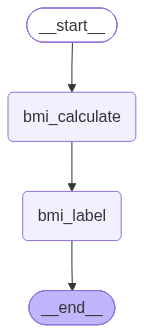

In [22]:
from IPython.display import Image, display

display(Image(workflow.get_graph().draw_mermaid_png()))